In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [23]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

In [11]:
DATA_PROCESSED_DIR = Path("dataset/processed")

In [13]:
train_data = pd.read_csv(DATA_PROCESSED_DIR / "train_full.csv")

In [15]:
print(f"Training data shape: {train_data.shape}")

Training data shape: (395381, 24)


In [21]:
train_data.head()

,id_user,timestamp_reg,email,gender,reg_country,traffic_type,is_fraud,trans_count,total_amount,mean_amount,fail_count,success_count,unique_cards,unique_pay_countries,unique_error_groups,success_rate,mins_to_first_trans,activity_duration_mins,match_reg_pay,match_reg_card,match_pay_card,total_geo_mismatch,card_type,transaction_type
0,15383249,2025-07-16 19:01:23.868869+00:00,larsjohansson@gmail.com,male,Sweden,cpa,0,536,7353.30,13.718843,234,302,10,1,7,0.563433,80.335519,187326.733333,1,1,1,0,DEBIT,card_init
1,9458117,2025-05-04 19:30:02.902877+00:00,evamark@yahoo.com,male,Romania,cpa,0,52,145.73,2.802500,4,48,49,1,4,0.923077,183555.834952,162808.483333,1,1,1,0,DEBIT,card_init
2,21312302,2025-09-07 18:24:51+00:00,stmark86@gmail.com,male,Austria,ppc,0,7,25.27,3.610000,3,4,1,1,2,0.571429,19.466667,937.433333,1,1,1,0,DEBIT,card_init
3,61828,2025-01-01 17:33:08.026088+00:00,robertwalker@gmail.com,male,Portugal,organic,1,8,27.84,3.480000,7,1,2,1,2,0.125000,133.591272,889.684156,1,1,1,0,DEBIT,card_init
4,13164211,2025-06-21 18:27:03.420098+00:00,sarah.miller@gmail.com,female,Belgium,organic,0,102,2839.60,27.839216,32,70,3,2,5,0.686275,792.709665,269837.100000,1,1,1,0,CREDIT,card_init


In [28]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 395381 entries, 0 to 395380
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id_user                 395381 non-null  int64  
 1   timestamp_reg           395381 non-null  str    
 2   email                   395063 non-null  str    
 3   gender                  395381 non-null  str    
 4   reg_country             395255 non-null  str    
 5   traffic_type            395381 non-null  str    
 6   is_fraud                395381 non-null  int64  
 7   trans_count             395381 non-null  int64  
 8   total_amount            395381 non-null  float64
 9   mean_amount             395381 non-null  float64
 10  fail_count              395381 non-null  int64  
 11  success_count           395381 non-null  int64  
 12  unique_cards            395381 non-null  int64  
 13  unique_pay_countries    395381 non-null  int64  
 14  unique_error_groups     395381 

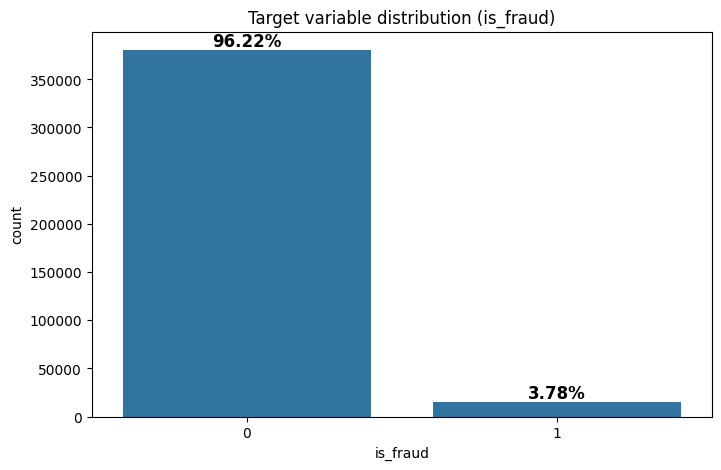

In [29]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train_data, x='is_fraud')
plt.title('Target variable distribution (is_fraud)')
total = len(train_data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

In [30]:
num_cols = ['total_amount', 'fail_count', 'unique_cards', 'mins_to_first_trans', 'activity_duration_mins']

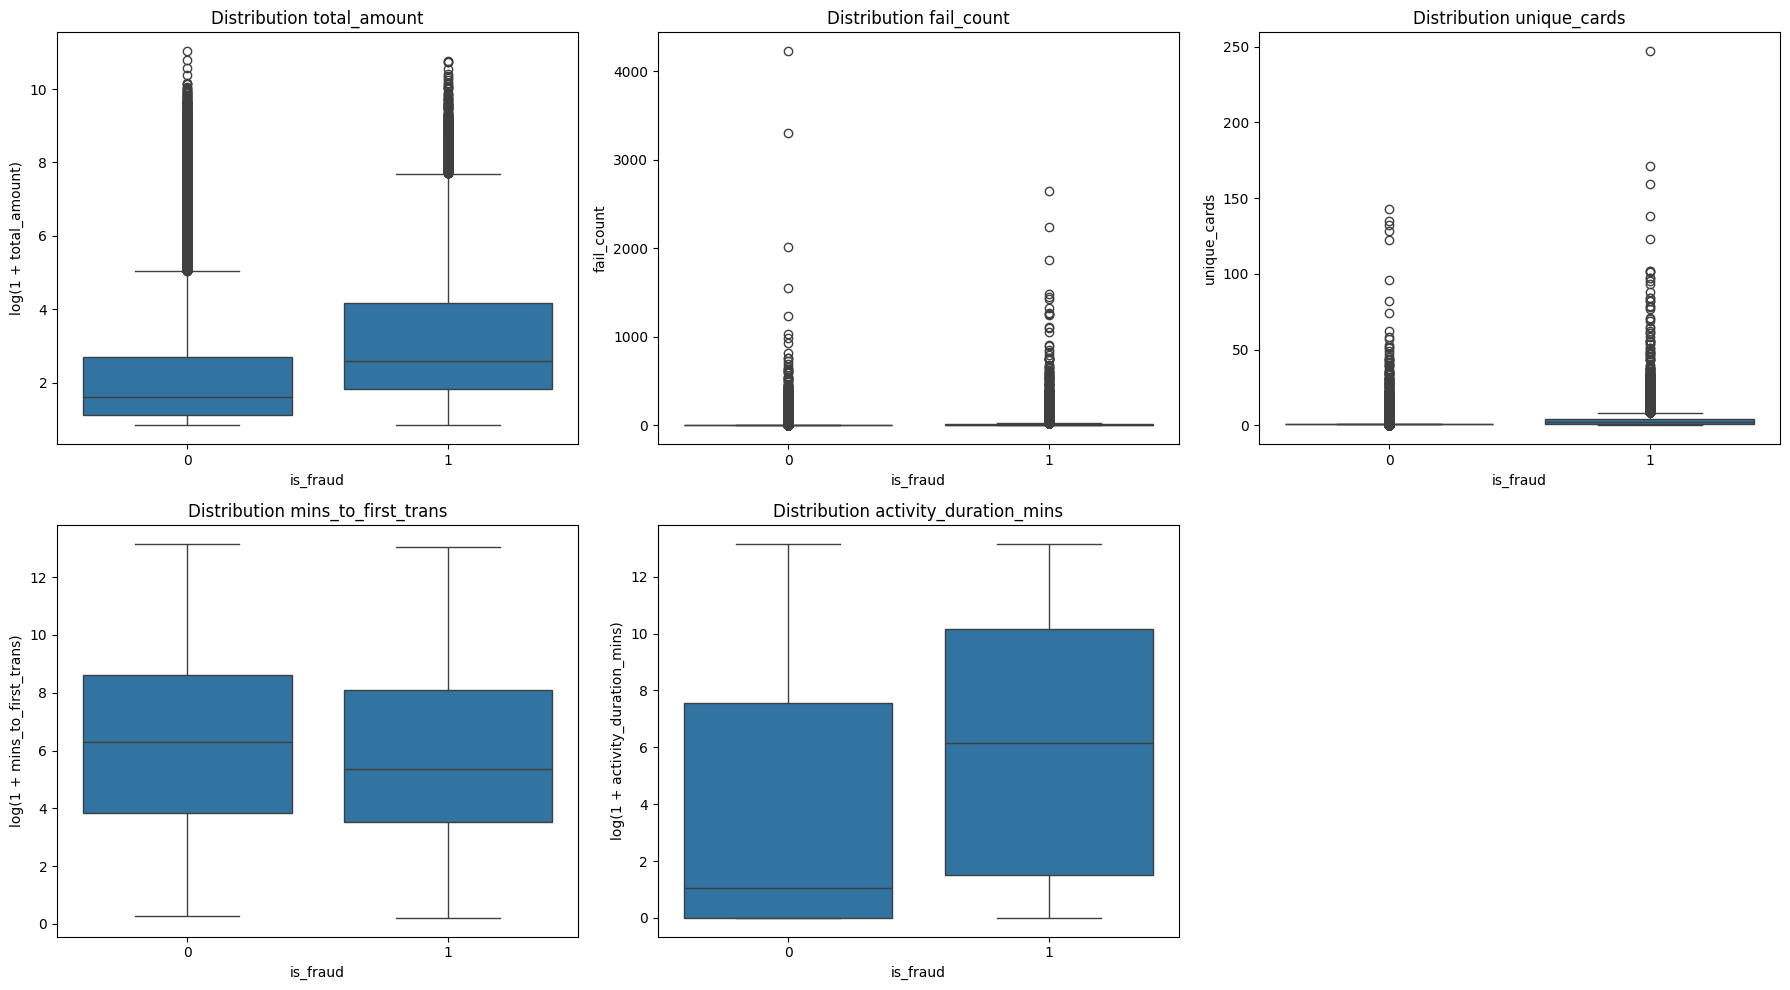

In [31]:
plt.figure(figsize=(18, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    if col in ['total_amount', 'mins_to_first_trans', 'activity_duration_mins']:
        sns.boxplot(data=train_data, x='is_fraud', y=np.log1p(train_data[col]))
        plt.ylabel(f'log(1 + {col})')
    else:
        sns.boxplot(data=train_data, x='is_fraud', y=col)
    plt.title(f'Distribution {col}')

plt.tight_layout()
plt.show()

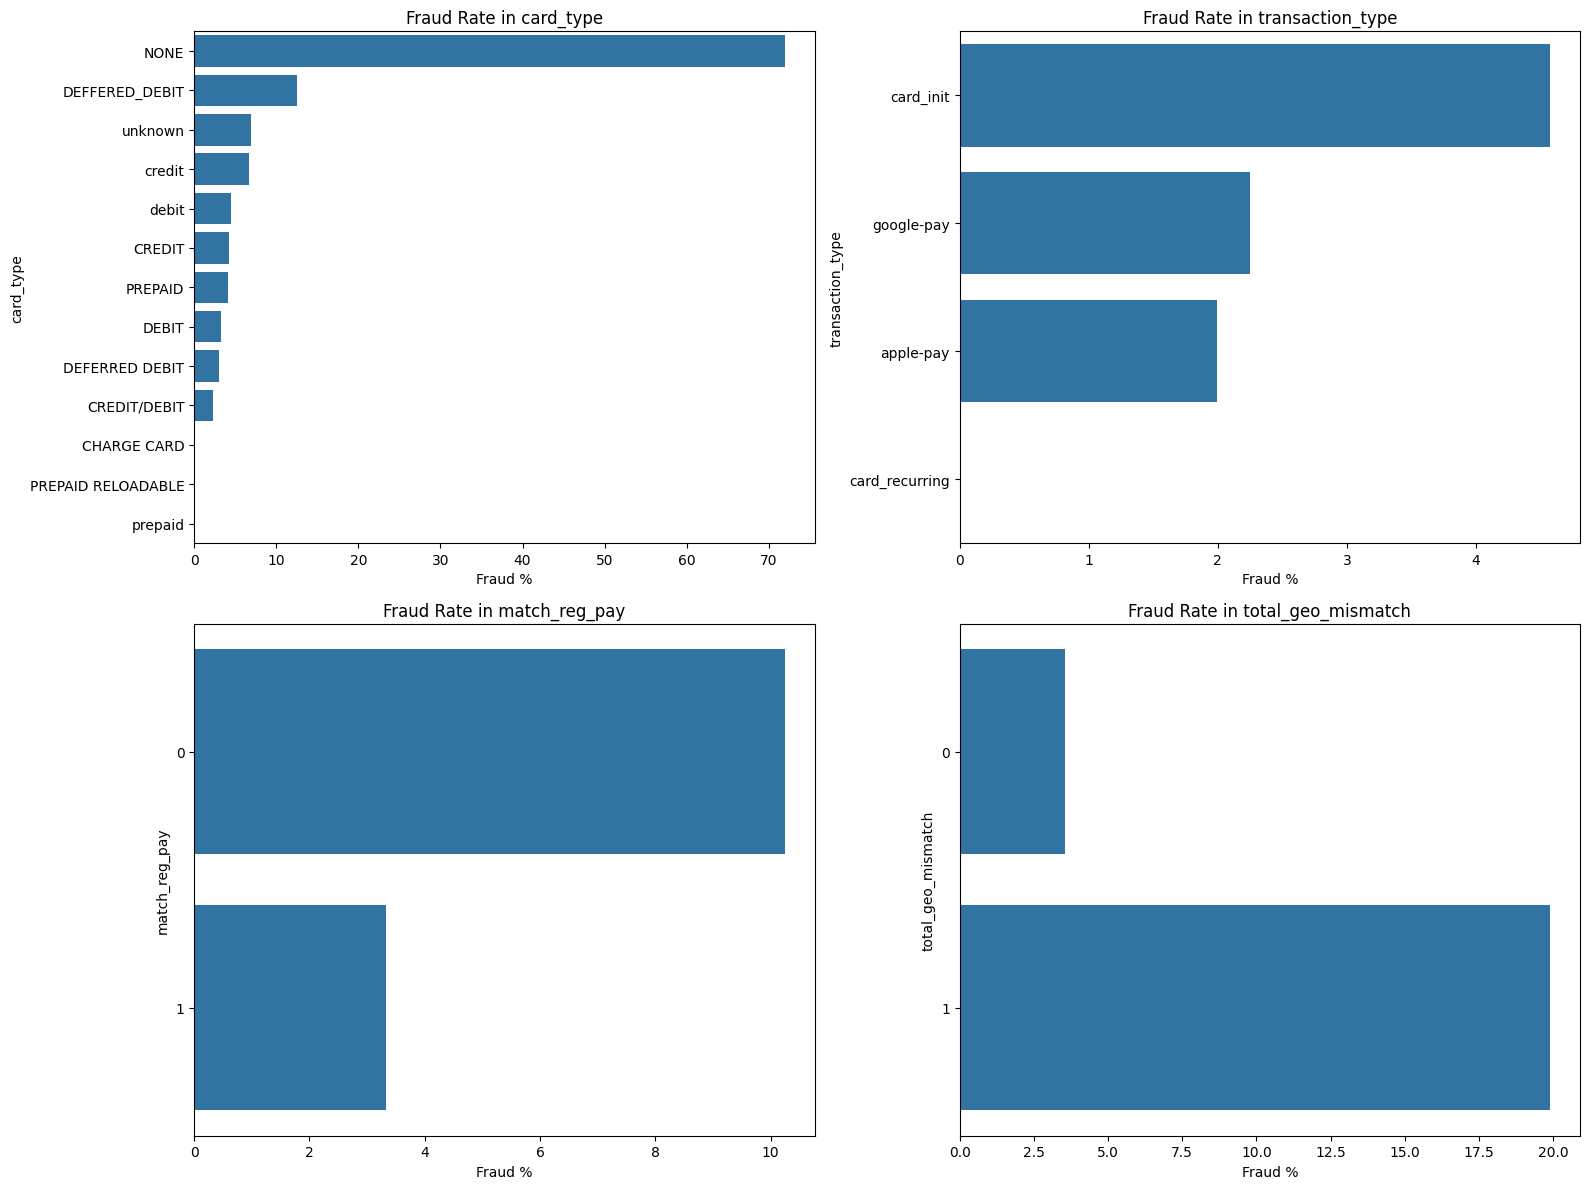

In [32]:
cat_cols = ['card_type', 'transaction_type', 'match_reg_pay', 'total_geo_mismatch']

plt.figure(figsize=(16, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    
    fraud_rate = train_data.groupby(col)['is_fraud'].mean().sort_values(ascending=False) * 100
    
    sns.barplot(x=fraud_rate.values, y=fraud_rate.index, orient='h')
    plt.title(f'Fraud Rate in {col}')
    plt.xlabel('Fraud %')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

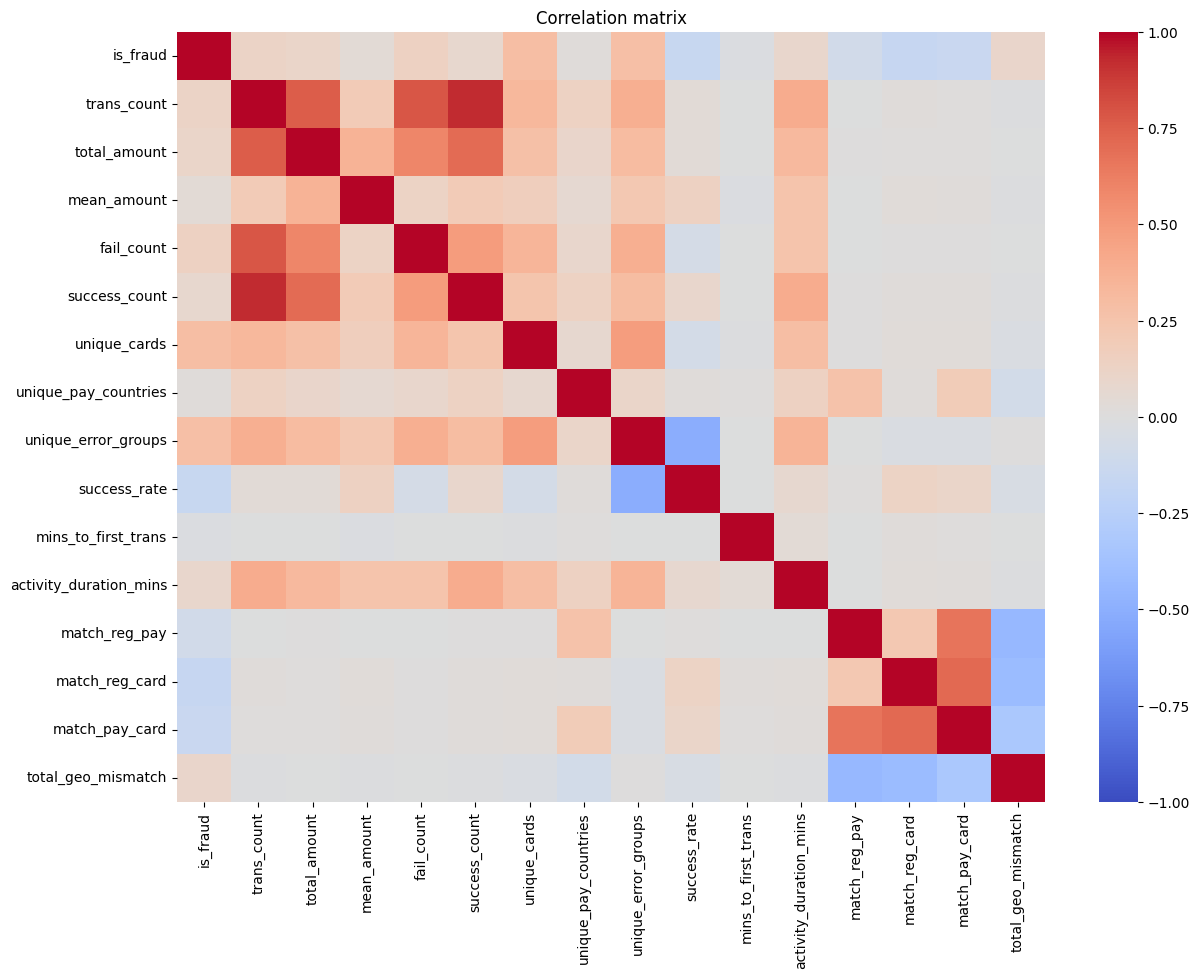

Top correlations with is_fraud:
unique_cards              0.289642
unique_error_groups       0.283556
fail_count                0.144710
trans_count               0.120681
total_amount              0.101900
total_geo_mismatch        0.098145
activity_duration_mins    0.091674
success_count             0.080216
mean_amount               0.042816
unique_pay_countries      0.020260
Name: is_fraud, dtype: float64


In [33]:
num_df = train_data.select_dtypes(include=[np.number]).drop(columns=['id_user'], errors='ignore')

plt.figure(figsize=(14, 10))
corr = num_df.corr()

# Строим тепловую карту
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation matrix')
plt.show()

# Top features with a high correlation with the target varible
print("Top correlations with is_fraud:")
print(corr['is_fraud'].sort_values(ascending=False).drop('is_fraud').head(10))